# Training Curves — All Attributes

Overlays every attribute's per-epoch train/test loss and accuracy curves (at
that attribute's best layer) on a single pair of axes, one figure per probe
type. Reads the `*_history.pkl` files written by
[`train_control_probe.py`](../src/train_control_probe.py) /
[`train_reading_probe.py`](../src/train_reading_probe.py) via
`probe_common.train_attribute` — each holds a `history_by_layer[layer]` dict
of `train_loss` / `test_loss` / `train_acc` / `test_acc` lists (one entry per
epoch), plus the `best_layer` picked by best test accuracy.

Auto-discovers every `probe_checkpoints/<probe_type>/<dataset_tag>/` directory
and plots whichever attributes have finished training there, so it re-runs
cleanly as more attributes/probe types complete.

In [1]:
import glob
import os
import pickle

import matplotlib.pyplot as plt

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

CHECKPOINT_DIR = "../probe_checkpoints"

# Fixed attribute -> color order (data-viz categorical palette, slots 1-4),
# so an attribute keeps the same color across every figure/notebook run.
ATTRIBUTE_COLORS = {
    "gullibility": "#2a78d6",       # blue
    "rationality": "#eb6834",       # orange
    "seriousness": "#1baf7a",       # aqua
    "certainty_seeking": "#eda100",  # yellow
}

## Discover available (probe_type, dataset_tag) runs

In [2]:
def discover_runs(checkpoint_dir):
    """Yield (probe_type, dataset_tag, {attribute: history_dict}) for every
    dataset-tag directory found under each probe_type/, using whichever
    attributes have a *_history.pkl there."""
    for probe_type in sorted(os.listdir(checkpoint_dir)):
        probe_dir = os.path.join(checkpoint_dir, probe_type)
        if not os.path.isdir(probe_dir):
            continue
        for dataset_tag in sorted(os.listdir(probe_dir)):
            tag_dir = os.path.join(probe_dir, dataset_tag)
            history_paths = sorted(glob.glob(os.path.join(tag_dir, "*_history.pkl")))
            if not history_paths:
                continue
            histories = {}
            for path in history_paths:
                attribute = os.path.basename(path).replace("_history.pkl", "")
                with open(path, "rb") as f:
                    histories[attribute] = pickle.load(f)
            yield probe_type, dataset_tag, histories


runs = list(discover_runs(CHECKPOINT_DIR))
for probe_type, dataset_tag, histories in runs:
    attrs = ", ".join(f"{a} (layer {h['best_layer']})" for a, h in histories.items())
    print(f"{probe_type}/{dataset_tag}: {attrs}")

control_probe/llama2_sample2+claudeopus_sample2: certainty_seeking (layer 21), gullibility (layer 16), rationality (layer 35), seriousness (layer 15)
reading_probe/llama2_sample2+claudeopus_sample2: certainty_seeking (layer 17), gullibility (layer 16), rationality (layer 30), seriousness (layer 15)


## Plot: all attributes' loss + accuracy curves, per probe type

saved ../probe_checkpoints/control_probe/llama2_sample2+claudeopus_sample2/plots/all_attributes_training_curves.png


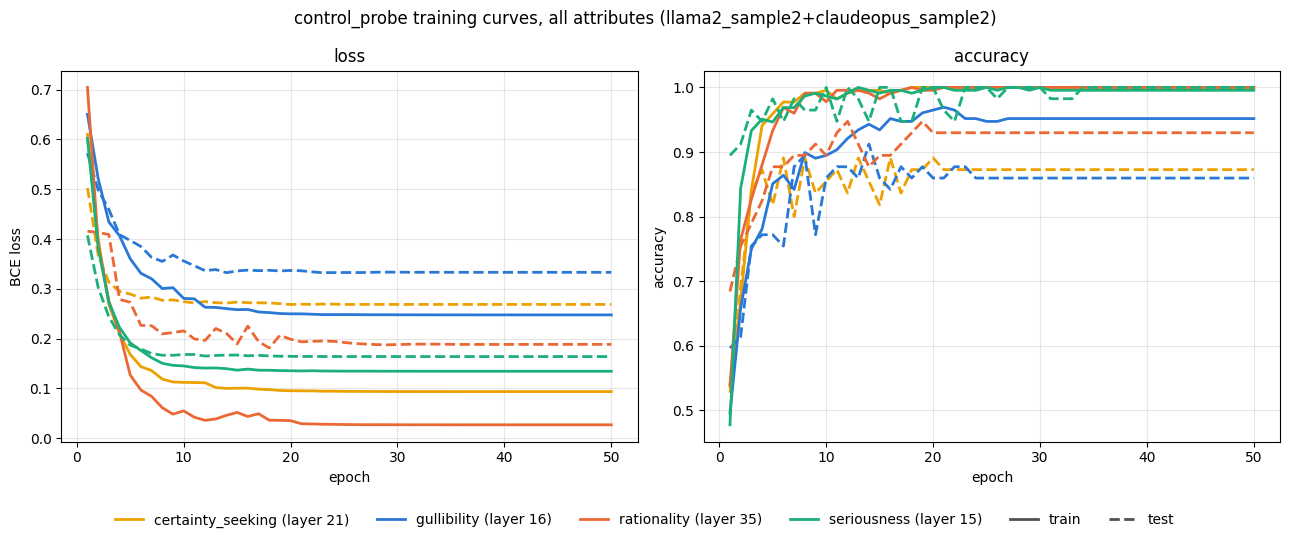

saved ../probe_checkpoints/reading_probe/llama2_sample2+claudeopus_sample2/plots/all_attributes_training_curves.png


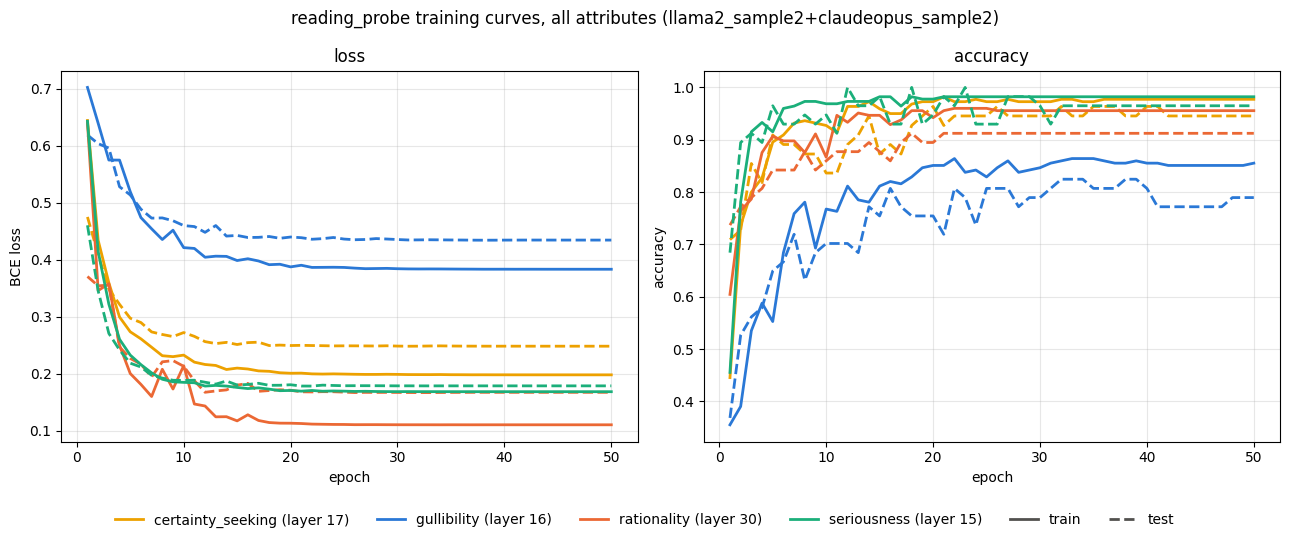

In [3]:
def plot_all_attributes(probe_type, dataset_tag, histories, out_path=None):
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13, 5))

    for attribute, history in sorted(histories.items()):
        color = ATTRIBUTE_COLORS.get(attribute, "#898781")
        best_layer = history["best_layer"]
        curves = history["history_by_layer"][best_layer]
        epochs = range(1, len(curves["train_loss"]) + 1)
        label = f"{attribute} (layer {best_layer})"

        ax_loss.plot(epochs, curves["train_loss"], color=color, linestyle="-", linewidth=2)
        ax_loss.plot(epochs, curves["test_loss"], color=color, linestyle="--", linewidth=2)

        ax_acc.plot(epochs, curves["train_acc"], color=color, linestyle="-", linewidth=2, label=label)
        ax_acc.plot(epochs, curves["test_acc"], color=color, linestyle="--", linewidth=2)

    ax_loss.set_xlabel("epoch")
    ax_loss.set_ylabel("BCE loss")
    ax_loss.set_title("loss")
    ax_loss.grid(alpha=0.3)

    ax_acc.set_xlabel("epoch")
    ax_acc.set_ylabel("accuracy")
    ax_acc.set_title("accuracy")
    ax_acc.grid(alpha=0.3)

    # One legend entry per attribute (color = attribute, from ax_acc's labeled
    # lines), plus a solid/dashed key shared by both panels.
    attr_handles, attr_labels = ax_acc.get_legend_handles_labels()
    split_handles = [
        plt.Line2D([0], [0], color="#52514e", linestyle="-", linewidth=2),
        plt.Line2D([0], [0], color="#52514e", linestyle="--", linewidth=2),
    ]
    split_labels = ["train", "test"]
    fig.legend(
        attr_handles + split_handles, attr_labels + split_labels,
        loc="lower center", bbox_to_anchor=(0.5, -0.08),
        ncol=len(attr_handles) + 2, frameon=False,
    )

    fig.suptitle(f"{probe_type} training curves, all attributes ({dataset_tag})")
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"saved {out_path}")
    plt.show()


for probe_type, dataset_tag, histories in runs:
    out_path = os.path.join(
        CHECKPOINT_DIR, probe_type, dataset_tag, "plots", "all_attributes_training_curves.png",
    )
    plot_all_attributes(probe_type, dataset_tag, histories, out_path=out_path)

## Plot: accuracy vs. layer, all attributes

Does going deeper help or hurt? Each attribute trains one probe per layer
independently (`train_attribute`'s outer loop over `layers`), and
`best_acc_per_layer[layer]` / `final_acc_per_layer[layer]` record that layer's
test accuracy (best epoch / final epoch). Overlaying all attributes on one
x=layer axis shows whether accuracy rises with depth, plateaus, or peaks
mid-stack — and whether that peak (marked with a star, matching each
attribute's `best_layer`) lines up across attributes.

saved ../probe_checkpoints/control_probe/llama2_sample2+claudeopus_sample2/plots/all_attributes_accuracy_vs_layer.png


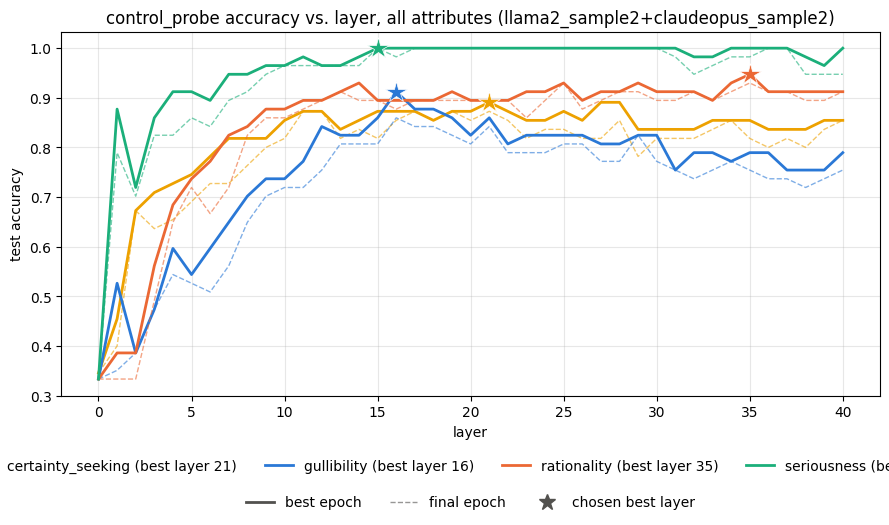

saved ../probe_checkpoints/reading_probe/llama2_sample2+claudeopus_sample2/plots/all_attributes_accuracy_vs_layer.png


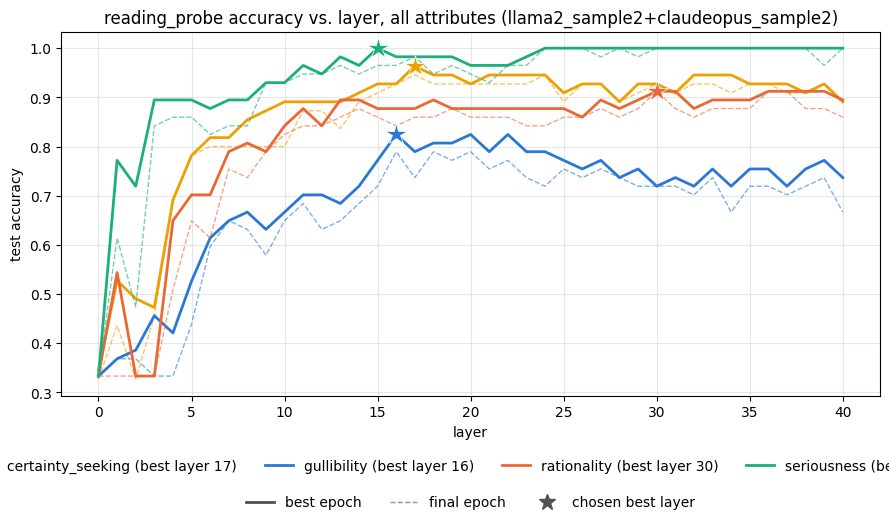

In [4]:
def plot_accuracy_vs_layer_all_attributes(probe_type, dataset_tag, histories, out_path=None):
    fig, ax = plt.subplots(figsize=(9, 5.5))

    for attribute, history in sorted(histories.items()):
        color = ATTRIBUTE_COLORS.get(attribute, "#898781")
        layers = sorted(history["best_acc_per_layer"].keys())
        best_acc = [history["best_acc_per_layer"][l] for l in layers]
        final_acc = [history["final_acc_per_layer"][l] for l in layers]
        best_layer = history["best_layer"]

        ax.plot(layers, best_acc, color=color, linestyle="-", linewidth=2,
                label=f"{attribute} (best layer {best_layer})")
        ax.plot(layers, final_acc, color=color, linestyle="--", linewidth=1, alpha=0.6)
        ax.plot(best_layer, history["best_acc_per_layer"][best_layer],
                marker="*", markersize=16, color=color, markeredgecolor="white", markeredgewidth=0.5,
                linestyle="none", zorder=5)

    ax.set_xlabel("layer")
    ax.set_ylabel("test accuracy")
    ax.grid(alpha=0.3)

    attr_handles, attr_labels = ax.get_legend_handles_labels()
    split_handles = [
        plt.Line2D([0], [0], color="#52514e", linestyle="-", linewidth=2),
        plt.Line2D([0], [0], color="#52514e", linestyle="--", linewidth=1, alpha=0.6),
        plt.Line2D([0], [0], color="#52514e", marker="*", markersize=12, linestyle="none"),
    ]
    split_labels = ["best epoch", "final epoch", "chosen best layer"]
    # Two stacked single-purpose legends (attribute colors, then line/marker
    # key) rather than one multi-column legend -- ncol>1 fills column-major,
    # which would interleave the two groups into overlapping rows.
    attr_legend = ax.legend(
        attr_handles, attr_labels, loc="upper center", bbox_to_anchor=(0.5, -0.14),
        ncol=len(attr_handles), frameon=False,
    )
    ax.add_artist(attr_legend)
    ax.legend(
        split_handles, split_labels, loc="upper center", bbox_to_anchor=(0.5, -0.24),
        ncol=len(split_handles), frameon=False,
    )

    ax.set_title(f"{probe_type} accuracy vs. layer, all attributes ({dataset_tag})")
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"saved {out_path}")
    plt.show()


for probe_type, dataset_tag, histories in runs:
    out_path = os.path.join(
        CHECKPOINT_DIR, probe_type, dataset_tag, "plots", "all_attributes_accuracy_vs_layer.png",
    )
    plot_accuracy_vs_layer_all_attributes(probe_type, dataset_tag, histories, out_path=out_path)